# IFN680 Project 6: The Sharpness Quest - main_report

**Group 4** - Karan Rooprai (n12498122), Nhu Hieu Nguyen (n12194778)

This notebook reproduces **every number, table and figure in the report**. It trains nothing. It loads the three checkpoints (`cVAE_Baseline.pth`, `cVAE_DiscriminatorLoss.pth`, `DigitClassifier.pth`), the two training records (`*_history.json`) and the test split (`mnist_custom_test.pt`), and evaluates both cVAEs on the 10,000 test images. It runs top to bottom in a few minutes on a CPU.

The hypothesis under test:

> *Adding a discriminator term to the loss function of a cVAE during training increases the sharpness of the reconstructed images.*

Every model and metric is explained where it is built: the cVAE in `cVAE_Baseline.ipynb` (section 3), the discriminator, the losses and the sharpness measures in `cVAE_DiscriminatorLoss.ipynb` (sections 4 to 8), and the classifier in `DigitClassifier.ipynb`. The lead-ins here say what each output is and how to read it.

**Sections:** 1 Setup, 2 Test data, 3 The models, 4 Checkpoints and training records, 5 Figure 1, 6 Reconstructions and samples, 7 Sharpness and pixel error, 8 Class consistency, 9 Frechet distances, 10 Diversity, 11 Figure 2, 12 Summary.

## 1 Setup

The libraries, the device and the seed. The printed versions make the executed notebook its own
record of where it ran. The palette cell below it keeps every figure in the same colours.

In [1]:
# The Week 8 tutorial's stack. json carries results from the training notebooks to
# main_report.ipynb, and make_grid lays out digit grids the way the tutorial's figures do.
import json
import platform

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.utils import make_grid

# The brief asks for the IFN680 GPU environment. The same code runs on a CPU when no GPU is
# visible, so the notebook runs anywhere and every tensor is placed with .to(device).
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"device      : {device}")
print(f"python      : {platform.python_version()}")
print(f"torch       : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"numpy       : {np.__version__}")

# One seed for everything: the data split, the initial weights and every random draw.
SEED = 0
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

device      : cuda:0
python      : 3.12.14
torch       : 2.13.0+cu126
torchvision : 0.28.0+cu126
numpy       : 2.5.3


In [2]:
# One palette for every figure in the project, so the figures read as a set.
INK, ACCENT, WARM = "#1f2933", "#2f6f9f", "#c1553b"
MUTED, PALE, GREEN = "#7b8794", "#e8ecf1", "#3f7d58"
plt.rcParams.update({"font.size": 8, "axes.titlesize": 8, "axes.edgecolor": MUTED,
                     "axes.spines.top": False, "axes.spines.right": False})

## 2 Test data

The 10,000 test images and their labels. The class counts matter later: samples are drawn under exactly these labels, so real and generated sets share one class mix.

In [3]:
# The test split, written by the training notebooks. This notebook is the only place it is
# scored. Z_DIM and NUM_CLASSES are the values the checkpoints were trained with.
Z_DIM, NUM_CLASSES = 7, 10
test_data = torch.load("mnist_custom_test.pt", weights_only=True)
test_images, test_labels = test_data["test_images"], test_data["test_labels"]
assert tuple(test_images.shape[1:]) == (1, 20, 20)
print(f"test_images : {tuple(test_images.shape)}, {test_images.dtype}")
print(f"test class counts : {torch.bincount(test_labels, minlength=10).tolist()}")
print(f"pixels exactly 1.0 : {(test_images == 1).float().mean():.3f}")

test_images : (10000, 1, 20, 20), torch.float32
test class counts : [980, 1135, 1032, 1010, 982, 892, 958, 1028, 974, 1009]
pixels exactly 1.0 : 0.700


## 3 The models

The class definitions, byte for byte the ones the checkpoints were trained with: the cVAE (`cVAE_Baseline.ipynb`, section 3), the discriminator (`cVAE_DiscriminatorLoss.ipynb`, section 5) and the classifier (`DigitClassifier.ipynb`, section 3).

In [4]:
# The tutorial's encoder with one change: the last convolution has a 3x3 kernel instead of
# 4x4, because on 20 x 20 images the map entering it is 3 x 3 (20 -> 10 -> 5 -> 3).
class cEncoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cEncoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        # Define the encoder layers
        self.encoder_backbone = nn.Sequential(
            # Layer 1: 1x20x20 -> 16x10x10
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 2: 16x10x10 -> 32x5x5
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 3: 32x5x5 -> 64x3x3
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 4: 64x3x3 -> 256x1x1 (the tutorial's kernel_size=4 fitted its 4x4 map)
            nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # Flatten and project to z_dim
            nn.Flatten(),  # 256*1*1 = 256
        )
        self.encoder_head = nn.Sequential(
            nn.Linear(256 + num_classes, 2 * z_dim)
        )

    def forward(self, x, cond):
        # x shape: (batch_size, 1, 20, 20); cond: (batch_size, num_classes), one-hot
        x = self.encoder_backbone(x)
        x = torch.cat([x, cond], dim=1)
        x = self.encoder_head(x)
        mu, logvar = torch.chunk(x, 2, dim=1)
        return mu, logvar

In [5]:
# The tutorial's decoder with the mirror-image change: the first transposed convolution has
# a 3x3 kernel, so the maps grow 1 -> 3 -> 5 -> 10 -> 20 and end at the image size.
class cDecoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cDecoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        self.decoder_input = nn.Sequential(
            # Project latent vector to a feature map
            nn.Linear(z_dim + num_classes, 256),
            nn.ReLU(),
        )
        self.decoder_backbone = nn.Sequential(
            nn.Unflatten(1, (256, 1, 1)),  # Reshape to (256, 1, 1)
            # Layer 1: 256x1x1 -> 64x3x3 (the tutorial's kernel_size=4 gave 64x4x4)
            nn.ConvTranspose2d(256, 64, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # Layer 2: 64x3x3 -> 32x5x5
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),
            # Layer 3: 32x5x5 -> 16x10x10
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # Layer 4: 16x10x10 -> 1x20x20
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0, 1] for pixel values
        )

    def forward(self, z, cond):
        z = torch.cat([z, cond], dim=1)
        z = self.decoder_input(z)
        x_hat = self.decoder_backbone(z)
        return x_hat

The cVAE, the discriminator and the classifier.

In [6]:
# The tutorial's cVAE, unchanged. forward() draws z with the reparameterisation trick, so the
# random draw stays outside the path the gradient has to flow through.
class cVAE(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cVAE, self).__init__()
        self.encoder = cEncoder(z_dim, num_classes)
        self.decoder = cDecoder(z_dim, num_classes)
        self.z_dim = z_dim
        self.num_classes = num_classes

    def encode(self, x, cond):
        return self.encoder(x, cond)

    def decode(self, z, cond):
        return self.decoder(z, cond)

    def forward(self, x, cond):
        mu, logvar = self.encoder(x, cond)
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(sigma)
        z = mu + eps * sigma
        x_recon = self.decoder(z, cond)
        return x_recon, mu, logvar

In [7]:
# The conditional discriminator. The class enters as ten constant image planes, so every
# convolution sees the image together with the class it is supposed to show.
class Discriminator(nn.Module):
    def __init__(self, num_classes=10, image_size=20):
        super().__init__()
        self.image_size = image_size
        self.net = nn.Sequential(
            # 11x20x20 -> 32x10x10: the image plus one plane per class
            nn.Conv2d(1 + num_classes, 32, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            # 32x10x10 -> 64x5x5
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            # 1600 features -> one logit: above 0 reads "real", below 0 reads "fake"
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 1),
        )

    def forward(self, x, cond):
        planes = cond[:, :, None, None].expand(-1, -1, self.image_size, self.image_size)
        return self.net(torch.cat([x, planes], dim=1))

The classifier, and the helpers that decode images and measure sharpness (`cVAE_DiscriminatorLoss.ipynb`, section 8).

In [8]:
# The evaluation classifier, in the style of lecture 9 p42's: two convolution blocks and a
# 128-unit layer. features() returns that layer, the space the Frechet distances use.
class DigitClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 32x10x10
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 64x5x5
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128), nn.ReLU(),
        )
        self.output_layer = nn.Linear(128, num_classes)

    def features(self, x):
        return self.feature_extractor(x)

    def forward(self, x):
        return self.output_layer(self.features(x))

In [9]:
# Decoding helpers shared by every notebook that draws digits. Reconstructions decode mu, as
# the tutorial's test pass does; samples decode codes drawn from N(0, I).
def reconstruct(model, images, labels, batch_size=1000):
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            x = images[start:start + batch_size].to(device)
            cond = F.one_hot(labels[start:start + batch_size].to(device), NUM_CLASSES).float()
            mu, _ = model.encode(x, cond)
            outputs.append(model.decode(mu, cond).cpu())
    return torch.cat(outputs)


def decode_latents(model, z, labels, batch_size=1000):
    """Decode latent codes z under classes labels: conditional sampling when z ~ N(0, I)."""
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(z), batch_size):
            cond = F.one_hot(labels[start:start + batch_size].to(device), NUM_CLASSES).float()
            outputs.append(model.decode(z[start:start + batch_size].to(device), cond).cpu())
    return torch.cat(outputs)


def sample_grid(model, z_grid):
    """Rows are the digits 0 to 9 and columns the codes in z_grid, as in the brief's example,
    so each column is one latent code decoded under all ten classes."""
    labels = torch.arange(NUM_CLASSES, device=device).repeat_interleave(len(z_grid))
    images = decode_latents(model, z_grid.repeat(NUM_CLASSES, 1), labels)
    return images, labels.cpu()

The sharpness measures and the convergence statistic.

In [10]:
# Sharpness as the variance of the Laplacian (Pech-Pacheco et al., 2000). The 3x3 kernel
# responds to curvature in brightness: large at a crisp edge, near zero in a smooth blur.
LAPLACE_WEIGHTS = [[0.0, 1.0, 0.0], [1.0, -4.0, 1.0], [0.0, 1.0, 0.0]]
LAPLACE_KERNEL = torch.tensor(LAPLACE_WEIGHTS, device=device).view(1, 1, 3, 3)


def laplacian_variance(images, batch_size=2000):
    """Per-image variance of the Laplacian response (valid convolution, 18 x 18 values)."""
    values = []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            response = F.conv2d(images[start:start + batch_size].to(device), LAPLACE_KERNEL)
            values.append(response.flatten(1).var(dim=1).cpu())
    return torch.cat(values).double().numpy()


# A second view of blur: the share of pixels that are neither background nor stroke.
MID_GREY = (0.1, 0.9)


def midgrey_fraction(images):
    grey = (images > MID_GREY[0]) & (images < MID_GREY[1])
    return grey.flatten(1).float().mean(dim=1).double().numpy()

In [11]:
# A run has converged when its mean development reconstruction loss over the last WINDOW
# epochs is within 1% of its mean over the WINDOW epochs before them.
def convergence(curve, window):
    last, previous = np.mean(curve[-window:]), np.mean(curve[-2 * window:-window])
    change = (last - previous) / previous
    return {"last_mean": float(last), "previous_mean": float(previous),
            "relative_change": float(change), "within_1pct": bool(abs(change) < 0.01)}

## 4 Checkpoints and training records

Both cVAE files hold one model per training seed. The printed parameter counts identify the architectures.

In [12]:
# The three checkpoints. Each holds plain state_dicts saved from the CPU; map_location puts
# them on this notebook's device. The cVAE files hold one trained model per seed.
def load_cvaes(path):
    checkpoint = torch.load(path, map_location=device, weights_only=True)
    models = {}
    for key in sorted(k for k in checkpoint if k.startswith("seed_")):
        network = cVAE(Z_DIM, num_classes=NUM_CLASSES).to(device)
        network.load_state_dict(checkpoint[key])
        models[int(key.split("_")[1])] = network.eval()
    return models, checkpoint


def parameter_count(module):
    return sum(p.numel() for p in module.parameters())


baseline, _ = load_cvaes("cVAE_Baseline.pth")
adversarial, adversarial_checkpoint = load_cvaes("cVAE_DiscriminatorLoss.pth")
assert sorted(baseline) == sorted(adversarial)
SEEDS = sorted(baseline)

In [13]:
# The discriminator is not needed to evaluate the cVAE; it is loaded to show the file is
# complete and to count its parameters. The classifier is the measuring instrument.
discriminator = Discriminator(NUM_CLASSES).to(device)
_ = discriminator.load_state_dict(adversarial_checkpoint["discriminator_seed_0"])
classifier = DigitClassifier(NUM_CLASSES).to(device)
_ = classifier.load_state_dict(torch.load("DigitClassifier.pth", map_location=device,
                                          weights_only=True))
_ = classifier.eval()
print(f"seeds loaded : {SEEDS} for both cVAEs")
print(f"parameters   : cVAE {parameter_count(baseline[0]):,} | "
      f"discriminator {parameter_count(discriminator):,} | "
      f"classifier {parameter_count(classifier):,}")

seeds loaded : [0, 1, 2] for both cVAEs
parameters   : cVAE 350,107 | discriminator 23,297 | classifier 225,034


### 4.1 How the models were trained

From the history files: the lambda chosen on the development split, the epochs and seeds, where training ran, and the time per epoch.

In [14]:
# The training records: the chosen lambda, the epochs, where the models were trained, and
# how long an epoch took. Every value comes from the files, never retyped.
with open("cVAE_Baseline_history.json") as handle:
    baseline_record = json.load(handle)
with open("cVAE_DiscriminatorLoss_history.json") as handle:
    adversarial_record = json.load(handle)
LAMBDA = adversarial_record["lambda"]
records = {"baseline": baseline_record, "discriminator loss": adversarial_record}
print(f"lambda (chosen on the development split) : {LAMBDA}")
for name, record in records.items():
    print(f"{name:<18} | epochs {record['epochs']} | seeds {record['seeds']} | "
          f"refit on {record['n_refit']:,} images | trained on {record['device']} | "
          f"seconds per epoch {record['seconds_per_epoch']:.2f}")

lambda (chosen on the development split) : 0.3
baseline           | epochs 150 | seeds [0, 1, 2] | refit on 60,000 images | trained on cuda:0 | seconds per epoch 2.09
discriminator loss | epochs 150 | seeds [0, 1, 2] | refit on 60,000 images | trained on cuda:0 | seconds per epoch 5.40


### 4.2 The lambda sweep and the convergence check

Each sweep row is one development run: its reconstruction loss and sharpness on the development split, the real development images' sharpness, and the discriminator's accuracy. The chosen lambda is the one whose sharpness comes closest to the real value without the discriminator winning outright. A run has converged when the change between its last two windows of epochs is within 1%.

In [15]:
# The lambda sweep, reprinted from the file, and the convergence statistic of each
# development run, re-derived here from its saved curve.
print("sweep | lambda | dev recon loss | dev sharpness | real dev sharpness | D accuracy")
for row in adversarial_record["sweep"]:
    print(f"sweep | {row['lambda']} | {row['dev_recon_loss']:.4f} | {row['dev_sharpness']:.4f} "
          f"| {row['real_dev_sharpness']:.4f} | {row['d_accuracy']:.4f}")
for name, record in records.items():
    check = convergence(record["dev"]["dev_recon"], record["window"])
    print(f"convergence | {name} | last {check['last_mean']:.4f} | "
          f"previous {check['previous_mean']:.4f} | change {check['relative_change']:+.4f} | "
          f"within 1% {check['within_1pct']}")
window = adversarial_record["window"]
final_accuracy = np.mean(adversarial_record["dev"]["dev_d_accuracy"][-window:])
print(f"discriminator accuracy, mean of the last {window} dev epochs : {final_accuracy:.4f}")

sweep | lambda | dev recon loss | dev sharpness | real dev sharpness | D accuracy
sweep | 0.03 | 1.1835 | 0.1466 | 0.2311 | 0.8749
sweep | 0.1 | 1.1954 | 0.1732 | 0.2311 | 0.7299
sweep | 0.3 | 1.2427 | 0.1909 | 0.2311 | 0.6331
sweep | 1.0 | 1.2233 | 0.1857 | 0.2311 | 0.5997
convergence | baseline | last 1.1656 | previous 1.1671 | change -0.0013 | within 1% True
convergence | discriminator loss | last 1.2427 | previous 1.2442 | change -0.0012 | within 1% True
discriminator accuracy, mean of the last 10 dev epochs : 0.6331


### 4.3 The latent codes

`z_grid` holds the 12 codes for the grids, and `z_eval` one code per test image for the measurements. Both models decode the same codes, so every sample comparison is paired.

In [16]:
# Every latent code comes from a CPU generator seeded with SEED and is only then moved to the
# device, so the codes, and everything decoded from them, match on any machine.
latent_generator = torch.Generator().manual_seed(SEED)
z_grid = torch.randn(12, Z_DIM, generator=latent_generator).to(device)
z_eval = torch.randn(len(test_labels), Z_DIM, generator=latent_generator).to(device)
print(f"z_grid {tuple(z_grid.shape)} and z_eval {tuple(z_eval.shape)}, drawn with seed {SEED}")

z_grid (12, 7) and z_eval (10000, 7), drawn with seed 0


## 5 Figure 1: the two 12 x 10 grids

Twelve samples per digit, digits as rows, the brief's layout. Column k of both grids is the same code `z_grid[k]`, so the two grids differ only by the model. The classifier's accuracy on each grid's 120 images is printed below it.

In [17]:
# The classifier's verdict on images that are meant to show given classes: whether its top
# choice is that class, and the probability it gives that class (its confidence).
def classify(images, labels, batch_size=2000):
    correct, confidence = [], []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            logits = classifier(images[start:start + batch_size].to(device))
            target = labels[start:start + batch_size].to(device)
            correct.append((logits.argmax(dim=1) == target).cpu())
            confidence.append(logits.softmax(dim=1).gather(1, target[:, None])[:, 0].cpu())
    return torch.cat(correct).double().numpy(), torch.cat(confidence).double().numpy()

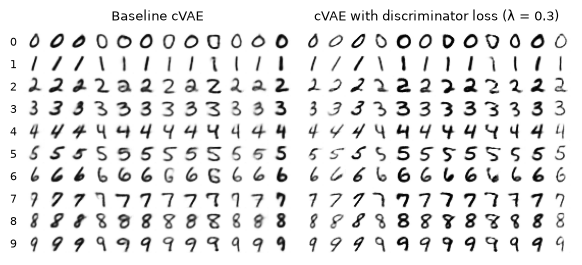

In [18]:
# Figure 1: both 12 x 10 grids from the same twelve latent codes, so each column is one code
# decoded by the two models. Rows are the digits 0 to 9.
titles = {"baseline": "Baseline cVAE",
          "adversarial": f"cVAE with discriminator loss (\u03bb = {LAMBDA})"}
grid_images = {"baseline": sample_grid(baseline[0], z_grid),
               "adversarial": sample_grid(adversarial[0], z_grid)}
fig, axes = plt.subplots(1, 2, figsize=(7.1, 3.25), gridspec_kw={"wspace": 0.03})
for ax, (key, (images, labels)) in zip(axes, grid_images.items()):
    ax.imshow(make_grid(images, nrow=12, pad_value=1)[0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(titles[key], fontsize=9)
    # The rows are the same digits in both grids, so only the left one is labelled.
    if ax is axes[0]:
        ax.set_yticks(12 + 22 * np.arange(10), [str(c) for c in range(10)], fontsize=8)
    else:
        ax.set_yticks([])
    ax.set_xticks([])
    ax.tick_params(length=0)
    for side in ("left", "bottom", "top", "right"):
        ax.spines[side].set_visible(False)
fig.savefig("figure_1_grids.pdf", bbox_inches="tight")
plt.show()

The classifier's accuracy on the 120 images of each grid.

In [19]:
# The share of each grid's 120 images the classifier recognises as the digit they were drawn as.
for key, (images, labels) in grid_images.items():
    correct, _ = classify(images, labels)
    print(f"grid accuracy | {titles[key]} | {correct.mean():.4f} of {len(correct)} images")

grid accuracy | Baseline cVAE | 1.0000 of 120 images
grid accuracy | cVAE with discriminator loss (λ = 0.3) | 0.9917 of 120 images


## 6 Reconstructions and samples

Every test image rebuilt from `mu` by each model and seed, and one sample per test image, drawn under that image's label from the shared code `z_eval`. The reconstructions test the hypothesis as the brief states it; the samples test the generation of Task 3.

In [20]:
# Every test image rebuilt from mu by every model (the objects the hypothesis is about), and
# one conditional sample per test image, under that image's own label, from the same code
# z_eval for both models. Every dictionary below is keyed by (model name, seed).
recon, samples = {}, {}
for name, models in (("baseline", baseline), ("adversarial", adversarial)):
    for seed in SEEDS:
        recon[name, seed] = reconstruct(models[seed], test_images, test_labels)
        samples[name, seed] = decode_latents(models[seed], z_eval, test_labels)
mse = {key: ((images - test_images) ** 2).flatten(1).mean(dim=1).double().numpy()
       for key, images in recon.items()}
print(f"{len(recon)} reconstruction sets and {len(samples)} sample sets of "
      f"{len(test_labels):,} images each")

6 reconstruction sets and 6 sample sets of 10,000 images each


## 7 Sharpness and pixel error

Each metric is printed with its **paired difference**, discriminator loss minus baseline, and a 95% bootstrap interval. If the interval excludes 0, the difference is not an accident of which test images were drawn. The per-seed differences show whether it survives retraining.

In [21]:
# A paired bootstrap: both models are scored on the same images (or the same latent codes),
# so the per-pair differences are resampled, 2,000 times, and the middle 95% of their means
# is the interval. A fresh generator per call keeps every interval independent of cell order.
def paired_bootstrap(before, after, resamples=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    difference = after - before
    means = np.array([difference[rng.integers(0, len(difference), len(difference))].mean()
                      for _ in range(resamples)])
    low, high = np.percentile(means, [2.5, 97.5])
    return float(difference.mean()), float(low), float(high)

In [22]:
# One printed line per metric: the real images' value where one exists, both models at seed 0,
# the paired difference (discriminator loss minus baseline) with its interval, and the same
# difference at every seed.
def metric_row(label, values, real=None, digits=4):
    before, after = values["baseline", 0], values["adversarial", 0]
    delta, low, high = paired_bootstrap(before, after)
    per_seed = [values["adversarial", s].mean() - values["baseline", s].mean() for s in SEEDS]
    real_text = f"{real.mean():.{digits}f}" if real is not None else "n/a"
    print(f"metric | {label} | real {real_text} | baseline {before.mean():.{digits}f} | "
          f"discriminator {after.mean():.{digits}f} | delta {delta:+.{digits}f} "
          f"[{low:+.{digits}f}, {high:+.{digits}f}] | seeds "
          + " ".join(f"{value:+.{digits}f}" for value in per_seed))
    return {"delta": delta, "low": low, "high": high, "seeds": per_seed}

The rows: pixel error of the reconstructions (`mse_recon`), then Laplacian variance (`sharpness_*`, higher is sharper, up to the real value) and mid-grey fraction (`midgrey_*`, lower is sharper), each for reconstructions and for samples.

In [23]:
# Pixel error, and the two views of sharpness, for reconstructions and for samples.
image_sets = {("recon",) + key: images for key, images in recon.items()}
image_sets.update({("sample",) + key: images for key, images in samples.items()})
sharpness = {key: laplacian_variance(images) for key, images in image_sets.items()}
grey = {key: midgrey_fraction(images) for key, images in image_sets.items()}
real_sharpness, real_grey = laplacian_variance(test_images), midgrey_fraction(test_images)


def by_kind(table, kind):
    return {key[1:]: value for key, value in table.items() if key[0] == kind}


rows = {"mse_recon": metric_row("mse_recon", mse, digits=5)}
for kind, label in (("recon", "reconstructions"), ("sample", "samples")):
    rows[f"sharpness_{kind}"] = metric_row(f"sharpness_{label}", by_kind(sharpness, kind),
                                           real=real_sharpness)
    rows[f"midgrey_{kind}"] = metric_row(f"midgrey_{label}", by_kind(grey, kind), real=real_grey)

metric | mse_recon | real n/a | baseline 0.01109 | discriminator 0.01194 | delta +0.00085 [+0.00080, +0.00090] | seeds +0.00085 +0.00238 +0.00067
metric | sharpness_reconstructions | real 0.2277 | baseline 0.1184 | discriminator 0.1931 | delta +0.0747 [+0.0741, +0.0753] | seeds +0.0747 +0.0728 +0.0810
metric | midgrey_reconstructions | real 0.1439 | baseline 0.2084 | discriminator 0.1533 | delta -0.0551 [-0.0556, -0.0547] | seeds -0.0551 -0.0555 -0.0590


metric | sharpness_samples | real 0.2277 | baseline 0.1141 | discriminator 0.2055 | delta +0.0913 [+0.0904, +0.0923] | seeds +0.0913 +0.0906 +0.0943
metric | midgrey_samples | real 0.1439 | baseline 0.2113 | discriminator 0.1469 | delta -0.0644 [-0.0651, -0.0637] | seeds -0.0644 -0.0662 -0.0672


### 7.1 The decision rule

The rule was fixed before the models were trained. The discriminator loss counts as sharpening an image set only if three things hold together: the Laplacian variance rises with an interval above 0, it rises at every seed, and the mid-grey fraction falls. It is applied to reconstructions and to samples separately.

In [24]:
# The decision rule, fixed before any of these numbers existed. "Sharper" needs a higher
# Laplacian variance whose interval lies above 0, the same sign at every seed, and a lower
# mid-grey fraction agreeing with it.
def sharper(sharp_row, grey_row):
    return bool(sharp_row["low"] > 0 and all(value > 0 for value in sharp_row["seeds"])
                and grey_row["delta"] < 0)


decisions = {kind: sharper(rows[f"sharpness_{kind}"], rows[f"midgrey_{kind}"])
             for kind in ("recon", "sample")}
print(f"decision | reconstructions sharper with the discriminator loss: {decisions['recon']}")
print(f"decision | samples sharper with the discriminator loss: {decisions['sample']}")

decision | reconstructions sharper with the discriminator loss: True
decision | samples sharper with the discriminator loss: True


## 8 Class consistency

The classifier's accuracy on the real test images is the reference point, not a ceiling: generated digits can be easier to read than the most unusual real handwriting. On the samples it measures how often a digit drawn as class c is recognised as c. Confidence is the probability it gives the intended class.

In [25]:
# Class consistency (lecture 9 p42 and p87): the classifier on the real test images once,
# then on each model's samples, which were drawn under the test images' own labels.
real_correct, real_confidence = classify(test_images, test_labels)
print(f"classifier | real test images | accuracy {real_correct.mean():.4f} | "
      f"confidence {real_confidence.mean():.4f}")
verdicts = {key: classify(images, test_labels) for key, images in samples.items()}
for name, label in (("baseline", "baseline"), ("adversarial", "discriminator")):
    correct, confidence = verdicts[name, 0]
    seeds_text = " ".join(f"{verdicts[name, s][0].mean():.4f}" for s in SEEDS)
    print(f"classifier | samples {label} | accuracy {correct.mean():.4f} | "
          f"confidence {confidence.mean():.4f} | seeds {seeds_text}")

classifier | real test images | accuracy 0.9836 | confidence 0.9727


classifier | samples baseline | accuracy 0.9855 | confidence 0.9699 | seeds 0.9855 0.9861 0.9879
classifier | samples discriminator | accuracy 0.9875 | confidence 0.9792 | seeds 0.9875 0.9877 0.9911


Per digit, at seed 0.

In [26]:
# The same accuracies per digit: a model can be strong overall and still fail one class.
labels_np = test_labels.numpy()
print("class | real   | baseline samples | discriminator samples")
for c in range(NUM_CLASSES):
    members = labels_np == c
    print(f"class {c} | {real_correct[members].mean():.4f} | "
          f"{verdicts['baseline', 0][0][members].mean():.4f} | "
          f"{verdicts['adversarial', 0][0][members].mean():.4f}")

class | real   | baseline samples | discriminator samples
class 0 | 0.9929 | 0.9939 | 0.9939
class 1 | 0.9991 | 0.9982 | 0.9991
class 2 | 0.9942 | 0.9874 | 0.9913
class 3 | 0.9901 | 0.9891 | 0.9950
class 4 | 0.9919 | 0.9857 | 0.9827
class 5 | 0.9922 | 1.0000 | 0.9944
class 6 | 0.9854 | 0.9864 | 0.9927
class 7 | 0.9854 | 0.9942 | 0.9932
class 8 | 0.9538 | 0.9548 | 0.9641
class 9 | 0.9495 | 0.9643 | 0.9673


## 9 Frechet distances

The Frechet distance compares two clouds of feature vectors by their means and covariances: 0 for identical clouds, larger as they drift apart. FID computes it in the features of an ImageNet network at 299 x 299 pixels; here it uses the digit classifier's 128-unit layer, built for 20 x 20 digits and available without a download.

In [27]:
# The classifier's 128-dimensional feature layer, for every image set, in float64.
def features(images, batch_size=2000):
    with torch.no_grad():
        parts = [classifier.features(images[start:start + batch_size].to(device)).cpu()
                 for start in range(0, len(images), batch_size)]
    return torch.cat(parts).double().numpy()


real_features = features(test_images)
sample_features = {key: features(images) for key, images in samples.items()}
recon_features = {key: features(images) for key, images in recon.items()}
print(f"feature vectors: {real_features.shape[1]} dimensions, "
      f"{1 + len(sample_features) + len(recon_features)} sets")

feature vectors: 128 dimensions, 13 sets


In [28]:
# The Frechet distance between two clouds of feature vectors, each summarised by its mean and
# covariance. tr sqrt(C_a C_b) comes from symmetric eigendecompositions, which stay real and
# exact where a general matrix square root can turn complex or print a warning.
def frechet_distance(a, b):
    mean_gap = ((a.mean(axis=0) - b.mean(axis=0)) ** 2).sum()
    cov_a, cov_b = np.cov(a, rowvar=False), np.cov(b, rowvar=False)
    values, vectors = np.linalg.eigh(cov_a)
    root_a = (vectors * np.sqrt(np.clip(values, 0, None))) @ vectors.T
    middle = np.linalg.eigvalsh(root_a @ cov_b @ root_a)
    cross = np.sqrt(np.clip(middle, 0, None)).sum()
    return float(mean_gap + np.trace(cov_a) + np.trace(cov_b) - 2 * cross)

The value depends on how many images are compared and in which class mix, so every comparison uses halves of equal size and mix, and the real-against-real value is the floor that no model can beat.

In [29]:
# Two class-stratified random halves of the test set. Comparing a generated set with half B,
# and half A with half B, keeps the size and the class mix of every comparison equal, so the
# real-against-real value is a fair floor.
rng = np.random.default_rng(SEED)
half_a, half_b = [], []
for c in range(NUM_CLASSES):
    members = rng.permutation(np.flatnonzero(labels_np == c))
    half_a.extend(members[:len(members) // 2])
    half_b.extend(members[len(members) // 2:])
half_a, half_b = np.sort(half_a), np.sort(half_b)
print(f"halves | A {len(half_a):,} | B {len(half_b):,}")

halves | A 4,999 | B 5,001


In [30]:
# Frechet distances: the floor, then each model's samples and reconstructions of half A
# (conditioned on half A's labels) against the real images of half B.
floor = frechet_distance(real_features[half_a], real_features[half_b])
print(f"frechet | floor, real A against real B | {floor:.2f}")
distances = {}
for kind, table in (("samples", sample_features), ("reconstructions", recon_features)):
    for key, values in table.items():
        distances[(kind,) + key] = frechet_distance(values[half_a], real_features[half_b])
    print(f"frechet | {kind} | baseline {distances[kind, 'baseline', 0]:.2f} | "
          f"discriminator {distances[kind, 'adversarial', 0]:.2f} | seeds baseline "
          + " ".join(f"{distances[kind, 'baseline', s]:.2f}" for s in SEEDS)
          + " | seeds discriminator "
          + " ".join(f"{distances[kind, 'adversarial', s]:.2f}" for s in SEEDS))

frechet | floor, real A against real B | 0.45
frechet | samples | baseline 51.32 | discriminator 4.81 | seeds baseline 51.32 56.71 52.93 | seeds discriminator 4.81 7.14 4.43
frechet | reconstructions | baseline 38.62 | discriminator 5.71 | seeds baseline 38.62 40.55 39.66 | seeds discriminator 5.71 7.18 4.89


## 10 Diversity

Mode collapse, a generator producing a few images again and again, is the classic failure of adversarial training. It shows as samples of one class that vary less than real digits of that class.

In [31]:
# Diversity: within each digit class, the total variance of the samples' features divided by
# that of the real images', averaged over classes. 1 matches real variety; well below 1 means
# the samples of a class look alike, the signature of mode collapse.
def spread_ratio(generated, real):
    ratios = [np.trace(np.cov(generated[labels_np == c], rowvar=False))
              / np.trace(np.cov(real[labels_np == c], rowvar=False)) for c in range(NUM_CLASSES)]
    return float(np.mean(ratios))


spread = {key: spread_ratio(values, real_features) for key, values in sample_features.items()}
print(f"spread | baseline {spread['baseline', 0]:.3f} | discriminator "
      f"{spread['adversarial', 0]:.3f} | seeds baseline "
      + " ".join(f"{spread['baseline', s]:.3f}" for s in SEEDS) + " | seeds discriminator "
      + " ".join(f"{spread['adversarial', s]:.3f}" for s in SEEDS))

spread | baseline 0.640 | discriminator 0.883 | seeds baseline 0.640 0.639 0.633 | seeds discriminator 0.883 0.865 0.879


## 11 Figure 2: reconstructions and training curves

(a) The first test image of each class, rebuilt by each model at seed 0. (b) The two development runs: the baseline and the chosen lambda.

In [32]:
# Figure 2: (a) one test digit per class, real and rebuilt by each seed-0 model; (b) the two
# development runs' reconstruction loss, with the discriminator's accuracy on a second axis.
# The figure is built over two cells, so it is a bare Figure, which Jupyter does not display
# until display() is called; a pyplot figure would appear half-drawn after this cell.
from matplotlib.figure import Figure
from IPython.display import display

first = [int(np.flatnonzero(labels_np == c)[0]) for c in range(NUM_CLASSES)]
strip = torch.cat([test_images[first], recon["baseline", 0][first],
                   recon["adversarial", 0][first]])
fig = Figure(figsize=(3.4, 2.3), layout="constrained")
ax_strip, ax_curve = fig.subplots(2, 1, gridspec_kw={"height_ratios": [1, 1.4]})
ax_strip.imshow(make_grid(strip, nrow=10, pad_value=1)[0], cmap="gray", vmin=0, vmax=1)
ax_strip.set_yticks(12 + 22 * np.arange(3), ["real", "baseline", "disc. loss"], fontsize=7)
ax_strip.set_xticks([])
ax_strip.tick_params(length=0)
ax_strip.set_title("(a) test digits and their reconstructions", fontsize=7)
for side in ("left", "bottom"):
    ax_strip.spines[side].set_visible(False)

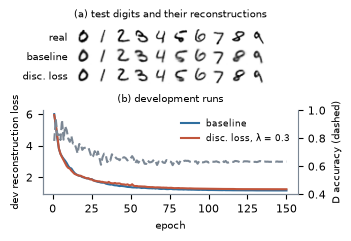

In [33]:
# Panel (b), then the figure is saved at the width of one report column.
epochs = np.arange(1, len(baseline_record["dev"]["dev_recon"]) + 1)
ax_curve.plot(epochs, baseline_record["dev"]["dev_recon"], color=ACCENT, label="baseline")
ax_curve.plot(epochs, adversarial_record["dev"]["dev_recon"], color=WARM,
              label=f"disc. loss, \u03bb = {LAMBDA}")
ax_curve.set_xlabel("epoch", fontsize=7)
ax_curve.set_ylabel("dev reconstruction loss", fontsize=7)
ax_curve.set_title("(b) development runs", fontsize=7)
twin = ax_curve.twinx()
twin.plot(epochs, adversarial_record["dev"]["dev_d_accuracy"], color=MUTED, linestyle="--",
          label="D accuracy")
twin.set_ylim(0.4, 1.0)
twin.set_ylabel("D accuracy (dashed)", fontsize=7)
twin.spines["right"].set_visible(True)
ax_curve.legend(frameon=False, fontsize=6.5, loc="upper right")
fig.savefig("figure_2_reconstructions.pdf", bbox_inches="tight")
display(fig)

## 12 Summary

The headline numbers in one machine-readable block.

In [34]:
# Every headline number in one machine-readable block, rounded as printed above.
summary = {
    "lambda": LAMBDA, "seeds": SEEDS, "decisions": decisions,
    "metrics": {name: {k: (round(v, 5) if isinstance(v, float) else [round(x, 5) for x in v])
                       for k, v in row.items()} for name, row in rows.items()},
    "classifier_real_accuracy": round(float(real_correct.mean()), 4),
    "classifier_sample_accuracy": {name: round(float(verdicts[name, 0][0].mean()), 4)
                                   for name in ("baseline", "adversarial")},
    "frechet_floor": round(floor, 2),
    "frechet_samples": {name: round(distances["samples", name, 0], 2)
                        for name in ("baseline", "adversarial")},
    "spread": {name: round(spread[name, 0], 3) for name in ("baseline", "adversarial")}}
print(json.dumps(summary, indent=1))

{
 "lambda": 0.3,
 "seeds": [
  0,
  1,
  2
 ],
 "decisions": {
  "recon": true,
  "sample": true
 },
 "metrics": {
  "mse_recon": {
   "delta": 0.00085,
   "low": 0.0008,
   "high": 0.0009,
   "seeds": [
    0.00085,
    0.00238,
    0.00067
   ]
  },
  "sharpness_recon": {
   "delta": 0.07468,
   "low": 0.07413,
   "high": 0.07528,
   "seeds": [
    0.07468,
    0.07284,
    0.08105
   ]
  },
  "midgrey_recon": {
   "delta": -0.05513,
   "low": -0.05559,
   "high": -0.05466,
   "seeds": [
    -0.05513,
    -0.05554,
    -0.05901
   ]
  },
  "sharpness_sample": {
   "delta": 0.09134,
   "low": 0.09035,
   "high": 0.09228,
   "seeds": [
    0.09134,
    0.09061,
    0.09432
   ]
  },
  "midgrey_sample": {
   "delta": -0.06441,
   "low": -0.06506,
   "high": -0.06372,
   "seeds": [
    -0.06441,
    -0.06623,
    -0.06722
   ]
  }
 },
 "classifier_real_accuracy": 0.9836,
 "classifier_sample_accuracy": {
  "baseline": 0.9855,
  "adversarial": 0.9875
 },
 "frechet_floor": 0.45,
 "frechet_